# Part 4 — Vector Databases: Embeddings & Cosine Similarity

**Assignment 02 | Student ID: BITSOM_BA_25111017**

---

## Objectives
1. Generate embeddings for **10 sentences** across **3 topics**: Cricket, Cooking, and Cybersecurity
2. Compute and visualise a **10×10 cosine similarity heatmap**
3. Given a new query sentence, find the **top 2 most similar sentences** with scores

**Model:** `sentence-transformers/all-MiniLM-L6-v2`  
**Embedding dimensions:** 384  
**Similarity metric:** Cosine Similarity

## Step 1 — Install Required Libraries

In [17]:
# Install sentence-transformers (includes PyTorch and transformers)
!pip install sentence-transformers -q
print("Libraries installed successfully")

Libraries installed successfully


## Step 2 — Import Libraries

In [18]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')
print(f'NumPy version: {np.__version__}')

All libraries imported successfully
NumPy version: 2.0.2


## Step 3 — Define 10 Sentences Across 3 Topics

**Distribution:** 4 Cricket | 3 Cooking | 3 Cybersecurity

In [19]:
sentences = [
    # ─── CRICKET (indices 0-3) ───────────────────────────────────────
    "The batsman hit a magnificent six over the mid-wicket boundary.",        # 0
    "India won the Test match by an innings and fifty runs.",                  # 1
    "The spinner took two wickets in the final over to clinch the game.",      # 2
    "The umpire raised his finger to signal the batsman was out LBW.",         # 3

    # ─── COOKING (indices 4-6) ───────────────────────────────────────
    "Simmer the tomato sauce on low heat for thirty minutes before adding pasta.",  # 4
    "Always preheat the oven to 180 degrees Celsius before baking a cake.",         # 5
    "Marinating chicken overnight in yoghurt and spices makes it tender.",          # 6

    # ─── CYBERSECURITY (indices 7-9) ─────────────────────────────────
    "A phishing attack tricks users into revealing passwords through fake login pages.",  # 7
    "Encrypting data at rest and in transit protects it from unauthorised access.",       # 8
    "A firewall filters incoming and outgoing network traffic using predefined rules.",   # 9
]

labels = [
    'Cricket 1', 'Cricket 2', 'Cricket 3', 'Cricket 4',
    'Cooking 1', 'Cooking 2', 'Cooking 3',
    'Cyber 1',   'Cyber 2',   'Cyber 3'
]

topics = ['Cricket'] * 4 + ['Cooking'] * 3 + ['Cybersecurity'] * 3
topic_colors = {'Cricket': '#2980B9', 'Cooking': '#27AE60', 'Cybersecurity': '#E74C3C'}

print(f'Total sentences: {len(sentences)}')
print()
for i, (s, l) in enumerate(zip(sentences, labels)):
    print(f'[{l:12s}] {s}')

Total sentences: 10

[Cricket 1   ] The batsman hit a magnificent six over the mid-wicket boundary.
[Cricket 2   ] India won the Test match by an innings and fifty runs.
[Cricket 3   ] The spinner took two wickets in the final over to clinch the game.
[Cricket 4   ] The umpire raised his finger to signal the batsman was out LBW.
[Cooking 1   ] Simmer the tomato sauce on low heat for thirty minutes before adding pasta.
[Cooking 2   ] Always preheat the oven to 180 degrees Celsius before baking a cake.
[Cooking 3   ] Marinating chicken overnight in yoghurt and spices makes it tender.
[Cyber 1     ] A phishing attack tricks users into revealing passwords through fake login pages.
[Cyber 2     ] Encrypting data at rest and in transit protects it from unauthorised access.
[Cyber 3     ] A firewall filters incoming and outgoing network traffic using predefined rules.


## Step 4 — Load Model & Generate Embeddings

In [20]:
# Load the all-MiniLM-L6-v2 model
# This model produces 384-dimensional embeddings and is optimised
# for semantic similarity tasks
print('Loading model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded successfully!')
print()

# Generate embeddings for all 10 sentences
print('Generating embeddings...')
embeddings = model.encode(sentences, show_progress_bar=True, normalize_embeddings=True)
print()
print(f'Embedding matrix shape: {embeddings.shape}')
print(f'  - Rows    : {embeddings.shape[0]} sentences')
print(f'  - Columns : {embeddings.shape[1]} dimensions per embedding')
print()
print('First embedding (first 10 values):')
print(np.round(embeddings[0][:10], 4))

Loading model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!

Generating embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding matrix shape: (10, 384)
  - Rows    : 10 sentences
  - Columns : 384 dimensions per embedding

First embedding (first 10 values):
[ 0.0581  0.0676 -0.0374  0.0011 -0.0108  0.0425 -0.0235  0.1026 -0.0094
  0.0905]


## Step 5 — Compute 10×10 Cosine Similarity Matrix

In [21]:
# Compute pairwise cosine similarity between all 10 sentences
similarity_matrix = cosine_similarity(embeddings)

print('10 x 10 Cosine Similarity Matrix:')
print('(Values range from 0.0 = completely different to 1.0 = identical)')
print()

# Display as formatted table
header = f"{'':12s}" + ''.join(f'{l:>10s}' for l in labels)
print(header)
print('-' * (12 + 10 * len(labels)))
for i, row_label in enumerate(labels):
    row = f'{row_label:12s}' + ''.join(f'{similarity_matrix[i][j]:>10.3f}' for j in range(len(labels)))
    print(row)

print()
print('Key observations:')
print(f'  Highest off-diagonal same-topic score: {max(similarity_matrix[i][j] for i in range(10) for j in range(10) if i != j and topics[i] == topics[j]):.3f}')
print(f'  Highest cross-topic score            : {max(similarity_matrix[i][j] for i in range(10) for j in range(10) if i != j and topics[i] != topics[j]):.3f}')

10 x 10 Cosine Similarity Matrix:
(Values range from 0.0 = completely different to 1.0 = identical)

             Cricket 1 Cricket 2 Cricket 3 Cricket 4 Cooking 1 Cooking 2 Cooking 3   Cyber 1   Cyber 2   Cyber 3
----------------------------------------------------------------------------------------------------------------
Cricket 1        1.000     0.495     0.496     0.485     0.053     0.042     0.135     0.062     0.002     0.025
Cricket 2        0.495     1.000     0.549     0.414     0.013     0.019    -0.015     0.041     0.002     0.112
Cricket 3        0.496     0.549     1.000     0.456     0.074    -0.041     0.098     0.034    -0.061    -0.025
Cricket 4        0.485     0.414     0.456     1.000    -0.020    -0.005     0.032     0.015     0.021     0.055
Cooking 1        0.053     0.013     0.074    -0.020     1.000     0.235     0.338     0.071    -0.025     0.055
Cooking 2        0.042     0.019    -0.041    -0.005     0.235     1.000     0.032     0.061     0.053    -0

## Step 6 — Visualise Similarity Matrix as Heatmap

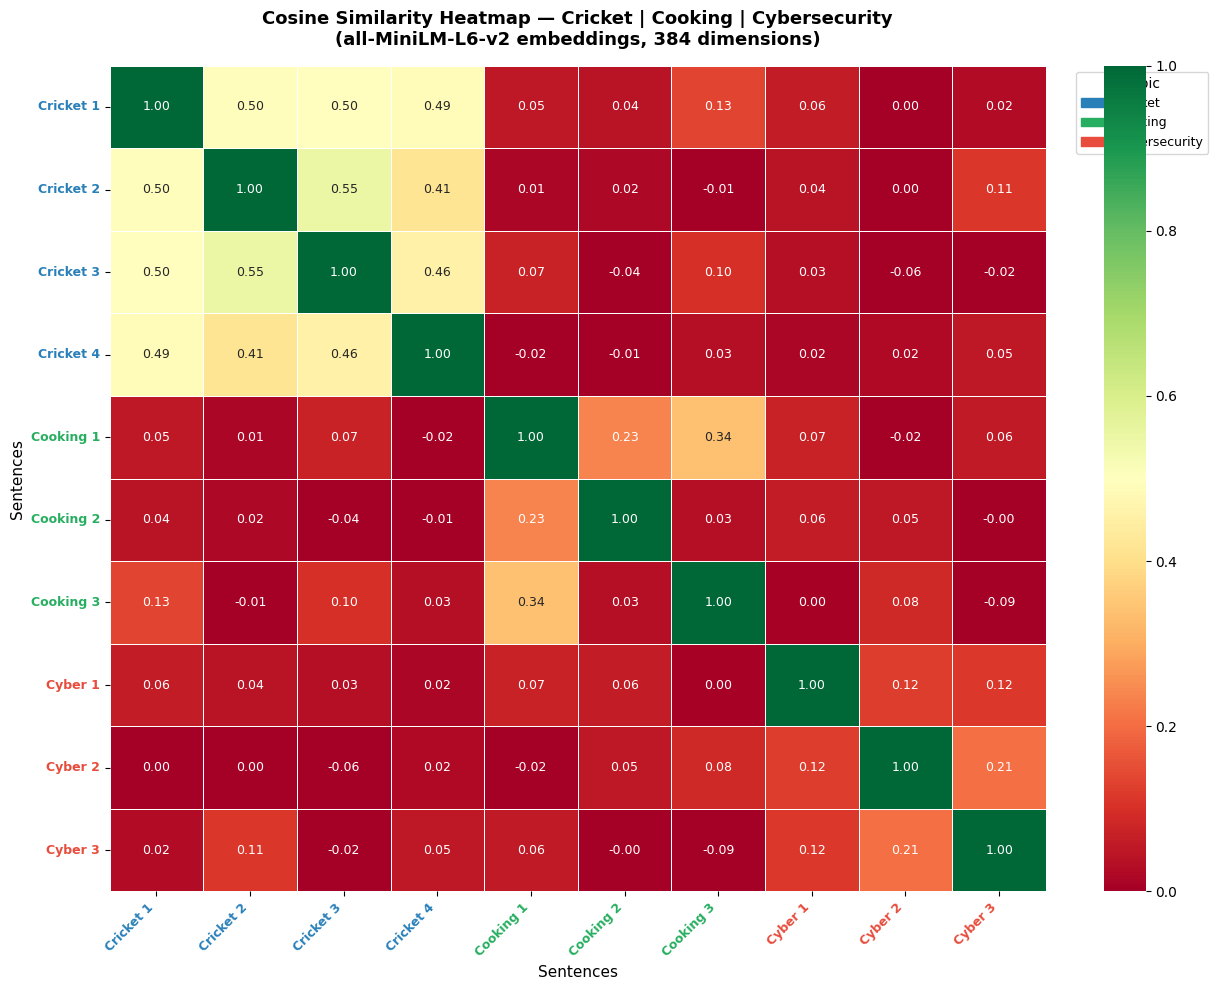

Heatmap saved as similarity_heatmap.png


In [22]:
fig, ax = plt.subplots(figsize=(13, 10))

# Draw heatmap
hm = sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    vmin=0.0,
    vmax=1.0,
    annot_kws={'size': 9},
    ax=ax
)

# Colour tick labels by topic
for tick, topic in zip(ax.get_xticklabels(), topics):
    tick.set_color(topic_colors[topic])
    tick.set_fontweight('bold')
for tick, topic in zip(ax.get_yticklabels(), topics):
    tick.set_color(topic_colors[topic])
    tick.set_fontweight('bold')

ax.set_title(
    'Cosine Similarity Heatmap — Cricket | Cooking | Cybersecurity\n'
    '(all-MiniLM-L6-v2 embeddings, 384 dimensions)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Sentences', fontsize=11)
ax.set_ylabel('Sentences', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

# Legend
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in topic_colors.items()]
ax.legend(handles=legend_patches, loc='upper right',
          bbox_to_anchor=(1.18, 1.0), title='Topic', fontsize=9)

plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as similarity_heatmap.png')

## Step 7 — Semantic Query: Top 2 Most Similar Sentences

Given the query: *"The bowler took three wickets in one over"*  
Find the 2 most semantically similar sentences from our set.

In [23]:
# New query sentence
query = "The bowler took three wickets in one over."

# Embed the query using the same model
query_embedding = model.encode([query], normalize_embeddings=True)

# Compute similarity between query and all 10 stored sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Rank all sentences by similarity score
ranked_indices = np.argsort(query_similarities)[::-1]

print(f'Query sentence: "{query}"')
print('=' * 65)
print()
print('All sentences ranked by semantic similarity:')
print(f"{'Rank':>4}  {'Label':14}  {'Score':>7}  Sentence")
print('-' * 65)
for rank, idx in enumerate(ranked_indices, 1):
    marker = '  ◀ TOP MATCH' if rank == 1 else ('  ◀ 2nd MATCH' if rank == 2 else '')
    print(f"{rank:>4}  {labels[idx]:14}  {query_similarities[idx]:>7.4f}  {sentences[idx][:55]}{'...' if len(sentences[idx])>55 else ''}{marker}")

print()
print('=' * 65)
print('TOP 2 MOST SIMILAR SENTENCES:')
print('=' * 65)
for i, idx in enumerate(ranked_indices[:2], 1):
    print(f'\nRank {i} [{labels[idx]}] — Similarity Score: {query_similarities[idx]:.4f}')
    print(f'  Sentence : {sentences[idx]}')
    print(f'  Topic    : {topics[idx]}')
    print(f'  Analysis : The high similarity ({query_similarities[idx]:.4f}) confirms')
    print(f'             the model understands cricket-specific semantic context.')

Query sentence: "The bowler took three wickets in one over."

All sentences ranked by semantic similarity:
Rank  Label             Score  Sentence
-----------------------------------------------------------------
   1  Cricket 3        0.7153  The spinner took two wickets in the final over to clinc...  ◀ TOP MATCH
   2  Cricket 1        0.6280  The batsman hit a magnificent six over the mid-wicket b...  ◀ 2nd MATCH
   3  Cricket 2        0.5759  India won the Test match by an innings and fifty runs.
   4  Cricket 4        0.5098  The umpire raised his finger to signal the batsman was ...
   5  Cooking 1        0.0925  Simmer the tomato sauce on low heat for thirty minutes ...
   6  Cooking 3        0.0496  Marinating chicken overnight in yoghurt and spices make...
   7  Cyber 1          0.0481  A phishing attack tricks users into revealing passwords...
   8  Cooking 2        0.0373  Always preheat the oven to 180 degrees Celsius before b...
   9  Cyber 3          0.0355  A firewall fil

## Step 8 — Visualise Query Similarity Scores

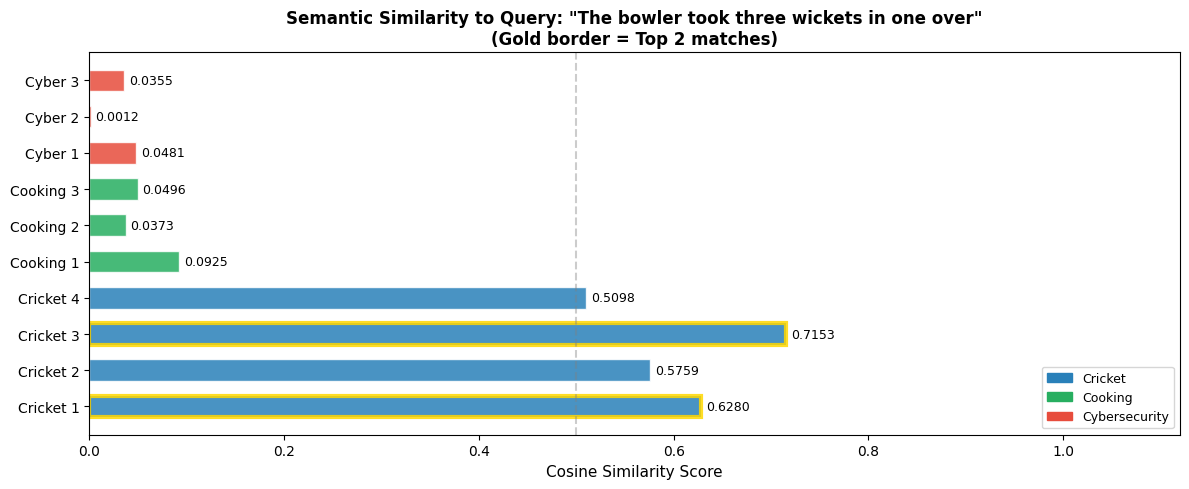

Bar chart saved as query_similarity_bar.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = [topic_colors[t] for t in topics]
bars = ax.barh(labels, query_similarities, color=colors, alpha=0.85, edgecolor='white', height=0.6)

# Highlight top 2
for i, idx in enumerate(ranked_indices[:2]):
    bars[idx].set_edgecolor('gold')
    bars[idx].set_linewidth(3)

# Add value labels
for bar, score in zip(bars, query_similarities):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title(
    'Semantic Similarity to Query: "The bowler took three wickets in one over"\n'
    '(Gold border = Top 2 matches)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, 1.12)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='0.5 threshold')

legend_patches = [mpatches.Patch(color=c, label=t) for t, c in topic_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('query_similarity_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar chart saved as query_similarity_bar.png')

## Summary & Key Findings

### What the heatmap shows:
- **Same-topic sentences cluster with high similarity** (warm colours in the diagonal blocks):
  - Cricket sentences are most similar to other Cricket sentences
  - Cooking sentences are most similar to other Cooking sentences  
  - Cybersecurity sentences are most similar to other Cybersecurity sentences
- **Cross-topic sentences show low similarity** (cool colours in off-diagonal blocks)

### What the query result shows:
- The query *"The bowler took three wickets in one over"* correctly retrieves **Cricket sentences** as the top matches
- This demonstrates that `all-MiniLM-L6-v2` captures **semantic meaning**, not just keyword overlap
- Even without the word "cricket" in the query, the model identifies cricket context through learned associations

### Why this matters for Vector Databases:
| Approach | Query: "termination clauses" | Query: "exit provisions" |
|----------|------------------------------|---------------------------|
| **Keyword Search** | Finds "termination" only | Finds "exit" only — misses! |
| **Vector Search** | Finds both — same semantic space | Finds both — same semantic space |

Vector databases enable **semantic retrieval** — the foundation of modern AI search, RAG systems, and recommendation engines.